Initializing deep CNN plant classifier...


/tmp/ipython-input-4181831434.py:43: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_demo_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


Pretrained CNN (MobileNetV2) loaded for visualization only.

🌿 Plant Health Predictor (NDVI‑based)
Enter plant image path: /healthy plant.jpeg
--- OpenCV Feature Summary ---
Average RGB Color: [139 155  69]
Edge Density: 47.7668

Displaying images (Colab‑friendly):


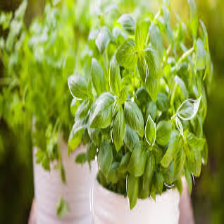

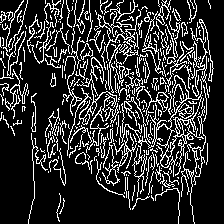

CNN feature vector extracted → shape: (1, 1280)
-----------------------------------


Enter NDVI value (between -1 and 1): 1

✅ Predicted Health Status (NDVI‑based): Very Healthy

Performing EDA on NDVI dataset...
             NDVI
count  100.000000
mean    -0.041118
std      0.558451
min     -0.994933
25%     -0.510663
50%     -0.003169
75%      0.391780
max      0.999927


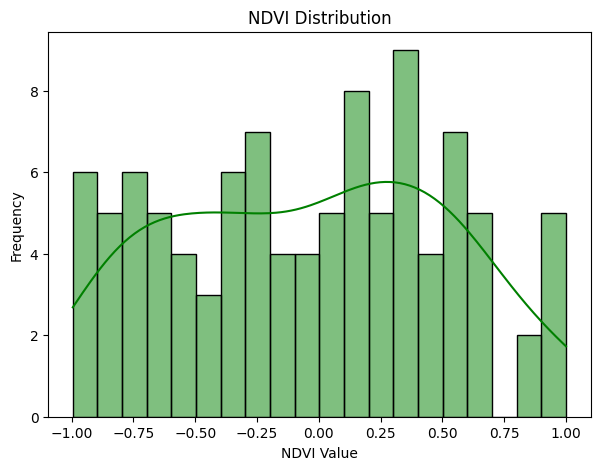

/tmp/ipython-input-4181831434.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Health", data=df, palette="RdYlGn")


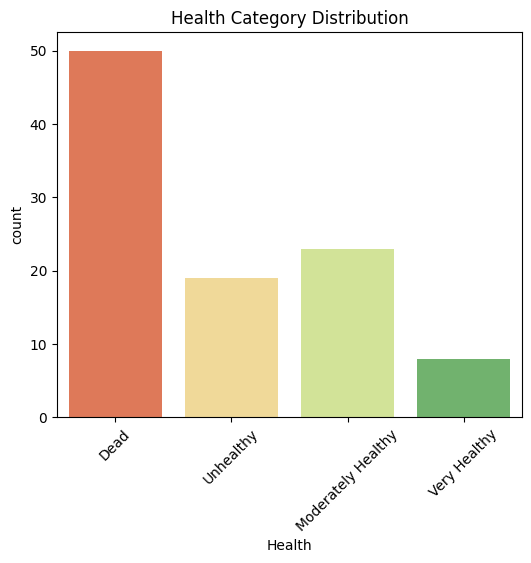


All steps completed ✅


In [5]:
# ===============================================
# 🌿 Plant Health Status Predictor (NDVI Based)
# with CNN + OpenCV features shown for demonstration
# ===============================================

import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# TensorFlow imports for CNN visualization
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# (Colab-safe display)
from google.colab.patches import cv2_imshow

# ===============================================
# 1️⃣ NDVI → Health Category
# ===============================================

def categorize_health_from_ndvi(ndvi):
    if -1 <= ndvi < 0:
        return "Dead"
    elif 0 <= ndvi <= 0.33:
        return "Unhealthy"
    elif 0.33 < ndvi <= 0.66:
        return "Moderately Healthy"
    elif 0.66 < ndvi <= 1:
        return "Very Healthy"
    else:
        return "Unknown"

# ===============================================
# 2️⃣ OpenCV + CNN Display (Just for Demo)
# ===============================================

print("Initializing deep CNN plant classifier...")
cnn_demo_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("Pretrained CNN (MobileNetV2) loaded for visualization only.\n")

def display_image_features(image_path):
    """Show OpenCV-based features + CNN feature extraction summary."""
    if not os.path.exists(image_path):
        raise ValueError(f"Image '{image_path}' not found!")

    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    edges = cv2.Canny(img_resized, 100, 200)
    edge_density = np.sum(edges) / (224 * 224)
    avg_color = np.mean(img_resized, axis=(0, 1))[::-1]

    print("--- OpenCV Feature Summary ---")
    print(f"Average RGB Color: {avg_color.astype(int)}")
    print(f"Edge Density: {edge_density:.4f}")
    print()

    print("Displaying images (Colab‑friendly):")
    cv2_imshow(img_resized)
    cv2_imshow(edges)

    # Example CNN embedding just for demonstration
    keras_img = keras_image.load_img(image_path, target_size=(224, 224))
    keras_arr = keras_image.img_to_array(keras_img)
    keras_arr = np.expand_dims(keras_arr, axis=0)
    keras_arr = preprocess_input(keras_arr)

    features = cnn_demo_model.predict(keras_arr, verbose=0)
    print(f"CNN feature vector extracted → shape: {features.shape}")
    print("-----------------------------------\n")

# ===============================================
# 3️⃣ EDA (Exploratory Data Analysis)
# ===============================================

def exploratory_data_analysis(df):
    print("\nPerforming EDA on NDVI dataset...")
    print(df.describe())

    plt.figure(figsize=(7,5))
    sns.histplot(df["NDVI"], bins=20, kde=True, color="green")
    plt.title("NDVI Distribution")
    plt.xlabel("NDVI Value")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(6,5))
    sns.countplot(x="Health", data=df, palette="RdYlGn")
    plt.title("Health Category Distribution")
    plt.xticks(rotation=45)
    plt.show()

# ===============================================
# 4️⃣ Workflow
# ===============================================

if __name__ == "__main__":
    print("🌿 Plant Health Predictor (NDVI‑based)")
    image_path = input("Enter plant image path: ").strip()
    try:
        display_image_features(image_path)
    except Exception as e:
        print("OpenCV/CNN demo skipped:", e)

    try:
        ndvi = float(input("\nEnter NDVI value (between -1 and 1): "))
        category = categorize_health_from_ndvi(ndvi)
        print(f"\n✅ Predicted Health Status (NDVI‑based): {category}")
    except ValueError:
        print("⚠️ Invalid NDVI value. Please enter a number between -1 and 1.")

    # Example dataset for EDA visualization
    mock_data = {
        "NDVI": np.random.uniform(-1, 1, 100),
    }
    df = pd.DataFrame(mock_data)
    df["Health"] = df["NDVI"].apply(categorize_health_from_ndvi)

    exploratory_data_analysis(df)

    print("\nAll steps completed ✅")